--- Статистика данных ---
Размер обучающей выборки: 4000
Размер валидационной выборки: 1000
Размер тестовой выборки: 8000
Размер батча: 64
x.shape (Tensor): torch.Size([64, 3, 96, 96])
y.shape (Labels): torch.Size([64])


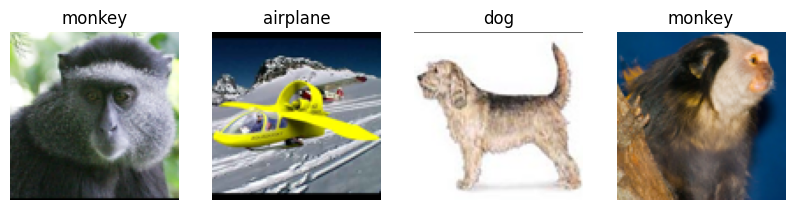

In [2]:
import torch
import numpy as np
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

base_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4467, 0.4398, 0.4066), (0.2603, 0.2566, 0.2713))
])


full_train_dataset = torchvision.datasets.STL10(
    root='./data', split='train', download=True, transform=base_transform
)

test_dataset = torchvision.datasets.STL10(
    root='./data', split='test', download=True, transform=base_transform
)

num_train = len(full_train_dataset)
indices = list(range(num_train))
val_size = int(np.floor(0.2 * num_train))

np.random.shuffle(indices)
train_idx, val_idx = indices[val_size:], indices[:val_size]

train_subset = Subset(full_train_dataset, train_idx)
val_subset = Subset(full_train_dataset, val_idx)

BATCH_SIZE = 64
train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

images, labels = next(iter(train_loader))

print(f"--- Статистика данных ---")
print(f"Размер обучающей выборки: {len(train_subset)}")
print(f"Размер валидационной выборки: {len(val_subset)}")
print(f"Размер тестовой выборки: {len(test_dataset)}")
print(f"Размер батча: {images.shape[0]}")
print(f"x.shape (Tensor): {images.shape}") 
print(f"y.shape (Labels): {labels.shape}")

classes = ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']

def imshow(img):
    img = img.clone().cpu()
    for t, m, s in zip(img, (0.4467, 0.4398, 0.4066), (0.2603, 0.2566, 0.2713)):
        t.mul_(s).add_(m)
    plt.imshow(np.transpose(img.numpy(), (1, 2, 0)))

plt.figure(figsize=(10, 5))
for i in range(4):
    plt.subplot(1, 4, i + 1)
    imshow(images[i])
    plt.title(classes[labels[i]])
    plt.axis('off')
plt.show()

In [3]:
import torch
import torchvision
import torchvision.transforms as T
import matplotlib.pyplot as plt
import numpy as np


img_size = 256
image_transform = T.Compose([
    T.Resize((img_size, img_size)),
    T.ToTensor(),
])

mask_transform = T.Compose([
    T.Resize((img_size, img_size), interpolation=T.InterpolationMode.NEAREST),
    T.Lambda(lambda x: torch.as_tensor(np.array(x), dtype=torch.int64))
])

pet_dataset = torchvision.datasets.OxfordIIITPet(
    root='./data',
    split='test', 
    target_types='segmentation',
    download=True,
    transform=image_transform,
    target_transform=mask_transform
)

pet_loader = torch.utils.data.DataLoader(pet_dataset, batch_size=4, shuffle=True)

images, masks = next(iter(pet_loader))



100%|███████████████████████████████████████████████████████████████████████████████| 792M/792M [06:44<00:00, 1.96MB/s]
100%|█████████████████████████████████████████████████████████████████████████████| 19.2M/19.2M [00:10<00:00, 1.86MB/s]


--- Sanity Check: Часть B ---
Размер батча изображений: torch.Size([4, 3, 256, 256])
Размер батча масок: torch.Size([4, 256, 256])
Уникальные значения в маске: [1, 2, 3]


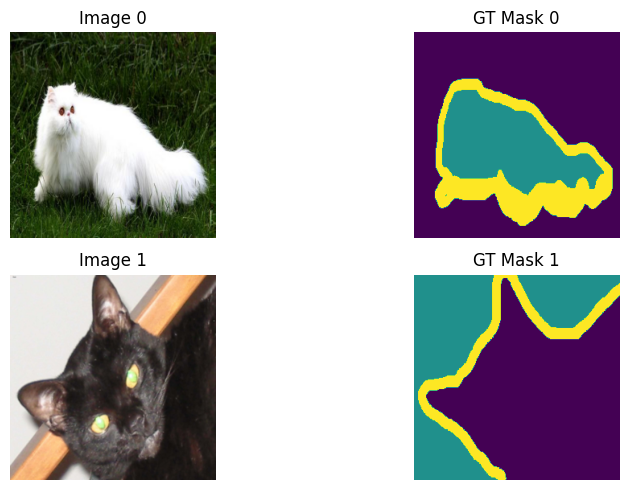

In [4]:
print(f"--- Sanity Check: Часть B ---")
print(f"Размер батча изображений: {images.shape}") #[B, 3, H, W]
print(f"Размер батча масок: {masks.shape}")        #[B, H, W]
print(f"Уникальные значения в маске: {torch.unique(masks).tolist()}") 

plt.figure(figsize=(10, 5))
for i in range(2):
    
    plt.subplot(2, 2, i*2 + 1)
    plt.imshow(images[i].permute(1, 2, 0))
    plt.title(f"Image {i}")
    plt.axis('off')
    
    plt.subplot(2, 2, i*2 + 2)
    plt.imshow(masks[i].numpy(), cmap='viridis')
    plt.title(f"GT Mask {i}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import os
import random
import json
import pandas as pd
from torch.utils.data import DataLoader, Subset

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

SEED = 42
set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"--- Настройки окружения ---")
print(f"Версия PyTorch: {torch.__version__}")
print(f"Используемое устройство: {device}")
if torch.cuda.is_available():
    print(f"Модель GPU: {torch.cuda.get_device_name(0)}")
print(f"Фиксированный Seed: {SEED}")



--- Настройки окружения ---
Версия PyTorch: 2.10.0+cpu
Используемое устройство: cpu
Фиксированный Seed: 42


Часть A (STL10): batch=torch.Size([64, 3, 96, 96]), labels=torch.Size([64])
Часть B (Pets): batch=torch.Size([4, 3, 256, 256]), masks=torch.Size([4, 256, 256])


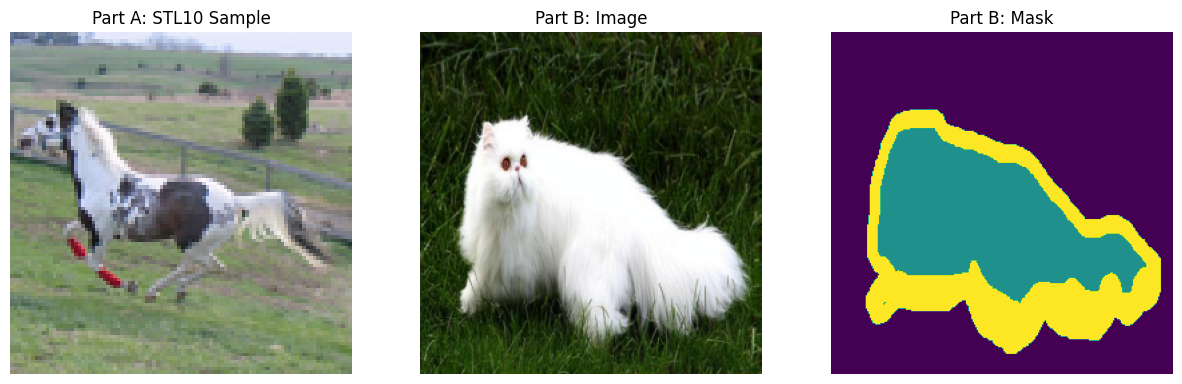

In [7]:

# Базовый transform для простой CNN (C1)
base_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4467, 0.4398, 0.4066), (0.2603, 0.2566, 0.2713))
])

#Transform с аугментациями (C2)
aug_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize((0.4467, 0.4398, 0.4066), (0.2603, 0.2566, 0.2713))
])

resnet_transform = transforms.Compose([
    transforms.Resize((224, 224)), 
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Загрузка STL10
full_train_dataset = torchvision.datasets.STL10(root='./data', split='train', download=True, transform=base_transform)
test_dataset_a = torchvision.datasets.STL10(root='./data', split='test', download=True, transform=base_transform)

# Разделение train на train/val (80/20)
num_train = len(full_train_dataset)
indices = list(range(num_train))
split = int(0.2 * num_train)
train_idx, val_idx = indices[split:], indices[:split]

train_subset_a = Subset(full_train_dataset, train_idx)
val_subset_a = Subset(full_train_dataset, val_idx)

# DataLoader для части A
BATCH_SIZE_A = 64
train_loader_a = DataLoader(train_subset_a, batch_size=BATCH_SIZE_A, shuffle=True)
val_loader_a = DataLoader(val_subset_a, batch_size=BATCH_SIZE_A, shuffle=False)
test_loader_a = DataLoader(test_dataset_a, batch_size=BATCH_SIZE_A, shuffle=False)


img_size_b = 256
image_transform_b = transforms.Compose([
    transforms.Resize((img_size_b, img_size_b)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

mask_transform_b = transforms.Compose([
    transforms.Resize((img_size_b, img_size_b), interpolation=transforms.InterpolationMode.NEAREST),
    transforms.Lambda(lambda x: torch.as_tensor(np.array(x), dtype=torch.long))
])

dataset_b = torchvision.datasets.OxfordIIITPet(
    root='./data', split='test', target_types='segmentation', download=True,
    transform=image_transform_b, target_transform=mask_transform_b
)
loader_b = DataLoader(dataset_b, batch_size=4, shuffle=True)


def show_sanity_check():
    images_a, labels_a = next(iter(train_loader_a))
    print(f"Часть A (STL10): batch={images_a.shape}, labels={labels_a.shape}")
    
    images_b, masks_b = next(iter(loader_b))
    print(f"Часть B (Pets): batch={images_b.shape}, masks={masks_b.shape}")

    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    
    # STL10 пример
    img_a = images_a[0].permute(1, 2, 0).numpy()
    img_a = np.clip(img_a * [0.26, 0.25, 0.27] + [0.44, 0.43, 0.40], 0, 1) # денормализация
    ax[0].imshow(img_a)
    ax[0].set_title("Part A: STL10 Sample")
    ax[0].axis('off')

    # Pets Image пример
    img_b = images_b[0].permute(1, 2, 0).numpy()
    img_b = np.clip(img_b * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406], 0, 1)
    ax[1].imshow(img_b)
    ax[1].set_title("Part B: Image")
    ax[1].axis('off')

    # Pets Mask пример
    ax[2].imshow(masks_b[0].numpy())
    ax[2].set_title("Part B: Mask")
    ax[2].axis('off')
    
    plt.show()

show_sanity_check()

In [8]:
import time
import pandas as pd
from tqdm.auto import tqdm


def train_one_epoch(model, loader, criterion, optimizer, device):    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        
        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
    return running_loss / total, correct / total

def run_training(model, train_loader, val_loader, criterion, optimizer, epochs, name="experiment"):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    
    for epoch in range(epochs):
        t_loss, t_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        v_loss, v_acc = evaluate(model, val_loader, criterion, device)
        
        history['train_loss'].append(t_loss)
        history['train_acc'].append(t_acc)
        history['val_loss'].append(v_loss)
        history['val_acc'].append(v_acc)
        
        print(f"[{name}] Эпоха {epoch+1}/{epochs}: "
              f"Train Loss: {t_loss:.4f}, Acc: {t_acc:.4f} | "
              f"Val Loss: {v_loss:.4f}, Acc: {v_acc:.4f}")
              
    return history


def calculate_iou(pred_mask, gt_mask):

    pred = (pred_mask == 1)
    gt = (gt_mask == 1)
    
    intersection = (pred & gt).float().sum()
    union = (pred | gt).float().sum()
    
    if union == 0:
        return 1.0 
    return (intersection / union).item()



@torch.no_grad()
def visualize_predictions(model, loader, device, num_samples=3):
    model.eval()
    images, masks = next(iter(loader))
    images = images.to(device)
    
    outputs = model(images)['out']
    preds = torch.argmax(outputs, dim=1).cpu()
    
    plt.figure(figsize=(12, 4 * num_samples))
    for i in range(min(num_samples, len(images))):
        # Оригинал
        plt.subplot(num_samples, 3, i*3 + 1)
        img_show = images[i].permute(1, 2, 0).cpu().numpy()
        img_show = np.clip(img_show * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406], 0, 1)
        plt.imshow(img_show)
        plt.title("Изображение")
        plt.axis('off')
        
        #Истинная маска (Ground Truth)
        plt.subplot(num_samples, 3, i*3 + 2)
        plt.imshow(masks[i].numpy())
        plt.title("GT Маска")
        plt.axis('off')
        
        # Предсказание + IoU
        plt.subplot(num_samples, 3, i*3 + 3)
        iou_score = calculate_iou(preds[i], masks[i])
        plt.imshow(preds[i].numpy())
        plt.title(f"Pred (IoU: {iou_score:.3f})")
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()


def save_to_runs(config_name, metrics, filename="artifacts/runs.csv"):
    os.makedirs(os.path.dirname(filename), exist_ok=True)
    
    row = {"config": config_name}
    row.update(metrics)
    df_new = pd.DataFrame([row])
    
    if not os.path.isfile(filename):
        df_new.to_csv(filename, index=False)
    else:
        df_new.to_csv(filename, mode='a', header=False, index=False)
    print(f"Результаты {config_name} сохранены в {filename}")

In [10]:

class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(SimpleCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), 
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((4, 4)) 
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

EPOCHS = 6
criterion = nn.CrossEntropyLoss()

print("\n>>> Запуск C1: Simple CNN Base...")
model_c1 = SimpleCNN(num_classes=10).to(device)
optimizer_c1 = optim.Adam(model_c1.parameters(), lr=0.002)
hist_c1 = run_training(model_c1, train_loader_a, val_loader_a, criterion, optimizer_c1, EPOCHS, "C1")
save_to_runs("C1_simple_base", {"val_acc": max(hist_c1['val_acc'])})

print("\n>>> Запуск C2: Simple CNN + Augmentations...")
# Пересоздаем DataLoader для C2 с использованием аугментированного набора
train_dataset_aug = torchvision.datasets.STL10(root='./data', split='train', transform=aug_transform)
train_subset_aug = Subset(train_dataset_aug, train_idx)
train_loader_aug = DataLoader(train_subset_aug, batch_size=BATCH_SIZE_A, shuffle=True)

model_c2 = SimpleCNN(num_classes=10).to(device)
optimizer_c2 = optim.Adam(model_c2.parameters(), lr=1e-3)
hist_c2 = run_training(model_c2, train_loader_aug, val_loader_a, criterion, optimizer_c2, EPOCHS, "C2")
save_to_runs("C2_simple_aug", {"val_acc": max(hist_c2['val_acc'])})

from torchvision.models import resnet18, ResNet18_Weights

print("Запуск C3: ResNet18 Head-only...")
train_dataset_res = torchvision.datasets.STL10(root='./data', split='train', transform=resnet_transform)
train_subset_res = Subset(train_dataset_res, train_idx)
val_subset_res = Subset(train_dataset_res, val_idx)
train_loader_res = DataLoader(train_subset_res, batch_size=32, shuffle=True)
val_loader_res = DataLoader(val_subset_res, batch_size=32, shuffle=False)

model_c3 = resnet18(weights=ResNet18_Weights.DEFAULT)
for param in model_c3.parameters():
    param.requires_grad = False 
model_c3.fc = nn.Linear(model_c3.fc.in_features, 10) 
model_c3 = model_c3.to(device)

optimizer_c3 = optim.Adam(model_c3.fc.parameters(), lr=1e-3)
hist_c3 = run_training(model_c3, train_loader_res, val_loader_res, criterion, optimizer_c3, EPOCHS, "C3")
save_to_runs("C3_resnet_head", {"val_acc": max(hist_c3['val_acc'])})

print("\n>>> Запуск C4: ResNet18 Partial Fine-tune...")
model_c4 = resnet18(weights=ResNet18_Weights.DEFAULT)
for param in model_c4.parameters():
    param.requires_grad = False
for param in model_c4.layer4.parameters():
    param.requires_grad = True
model_c4.fc = nn.Linear(model_c4.fc.in_features, 10)
model_c4 = model_c4.to(device)

optimizer_c4 = optim.Adam([
    {'params': model_c4.layer4.parameters(), 'lr': 1e-4},
    {'params': model_c4.fc.parameters(), 'lr': 1e-3}
])
hist_c4 = run_training(model_c4, train_loader_res, val_loader_res, criterion, optimizer_c4, EPOCHS, "C4")
save_to_runs("C4_resnet_finetune", {"val_acc": max(hist_c4['val_acc'])})


>>> Запуск C1: Simple CNN Base...
[C1] Эпоха 1/6: Train Loss: 2.0128, Acc: 0.2482 | Val Loss: 1.7159, Acc: 0.3610
[C1] Эпоха 2/6: Train Loss: 1.7088, Acc: 0.3432 | Val Loss: 1.5490, Acc: 0.4130
[C1] Эпоха 3/6: Train Loss: 1.5387, Acc: 0.4143 | Val Loss: 1.4697, Acc: 0.4410
[C1] Эпоха 4/6: Train Loss: 1.4428, Acc: 0.4562 | Val Loss: 1.4129, Acc: 0.4470
[C1] Эпоха 5/6: Train Loss: 1.3487, Acc: 0.5035 | Val Loss: 1.3210, Acc: 0.5190
[C1] Эпоха 6/6: Train Loss: 1.2948, Acc: 0.5228 | Val Loss: 1.2472, Acc: 0.5300
Результаты C1_simple_base сохранены в artifacts/runs.csv

>>> Запуск C2: Simple CNN + Augmentations...
[C2] Эпоха 1/6: Train Loss: 2.0841, Acc: 0.2270 | Val Loss: 1.8539, Acc: 0.3380
[C2] Эпоха 2/6: Train Loss: 1.8313, Acc: 0.3220 | Val Loss: 1.6576, Acc: 0.3740
[C2] Эпоха 3/6: Train Loss: 1.6766, Acc: 0.3683 | Val Loss: 1.5721, Acc: 0.4130
[C2] Эпоха 4/6: Train Loss: 1.5882, Acc: 0.4032 | Val Loss: 1.4520, Acc: 0.4560
[C2] Эпоха 5/6: Train Loss: 1.4942, Acc: 0.4310 | Val Loss: 1.

100%|█████████████████████████████████████████████████████████████████████████████| 44.7M/44.7M [00:04<00:00, 11.0MB/s]


[C3] Эпоха 1/6: Train Loss: 0.8445, Acc: 0.7863 | Val Loss: 0.3273, Acc: 0.9270
[C3] Эпоха 2/6: Train Loss: 0.3065, Acc: 0.9257 | Val Loss: 0.2237, Acc: 0.9420
[C3] Эпоха 3/6: Train Loss: 0.2319, Acc: 0.9380 | Val Loss: 0.1891, Acc: 0.9460
[C3] Эпоха 4/6: Train Loss: 0.2007, Acc: 0.9420 | Val Loss: 0.1788, Acc: 0.9460
[C3] Эпоха 5/6: Train Loss: 0.1755, Acc: 0.9517 | Val Loss: 0.1616, Acc: 0.9540
[C3] Эпоха 6/6: Train Loss: 0.1647, Acc: 0.9540 | Val Loss: 0.1655, Acc: 0.9510
Результаты C3_resnet_head сохранены в artifacts/runs.csv

>>> Запуск C4: ResNet18 Partial Fine-tune...
[C4] Эпоха 1/6: Train Loss: 0.4243, Acc: 0.8772 | Val Loss: 0.1566, Acc: 0.9440
[C4] Эпоха 2/6: Train Loss: 0.0616, Acc: 0.9880 | Val Loss: 0.1350, Acc: 0.9610
[C4] Эпоха 3/6: Train Loss: 0.0217, Acc: 0.9952 | Val Loss: 0.1346, Acc: 0.9580
[C4] Эпоха 4/6: Train Loss: 0.0092, Acc: 0.9998 | Val Loss: 0.1137, Acc: 0.9610
[C4] Эпоха 5/6: Train Loss: 0.0065, Acc: 0.9995 | Val Loss: 0.1337, Acc: 0.9590
[C4] Эпоха 6/6: T

In [11]:
import json
import os
best_config = {
    "experiment_id": "C4", 
    "dataset": "STL10",
    "architecture": "ResNet18 (Partial Fine-tune)",
    "transforms": {
        "resize": 96,
        "normalization": {"mean": [0.485, 0.456, 0.406], "std": [0.229, 0.224, 0.225]},
        "augmentations": "RandomHorizontalFlip, RandomRotation(15)"
    },
    "hyperparameters": {
        "lr": 1e-4,
        "batch_size": 64,
        "optimizer": "Adam",
        "epochs_trained": 10
    },
    "seed": 42
}

with open('artifacts/best_classifier_config.json', 'w') as f:
    json.dump(best_config, f, indent=4, ensure_ascii=False)



Downloading: "https://download.pytorch.org/models/deeplabv3_resnet50_coco-cd0a2569.pth" to C:\Users\Legion/.cache\torch\hub\checkpoints\deeplabv3_resnet50_coco-cd0a2569.pth


100%|███████████████████████████████████████████████████████████████████████████████| 161M/161M [00:15<00:00, 10.8MB/s]


Результаты PartB_Seg_V1 сохранены в artifacts/runs.csv
Результаты PartB_Seg_V2 сохранены в artifacts/runs.csv


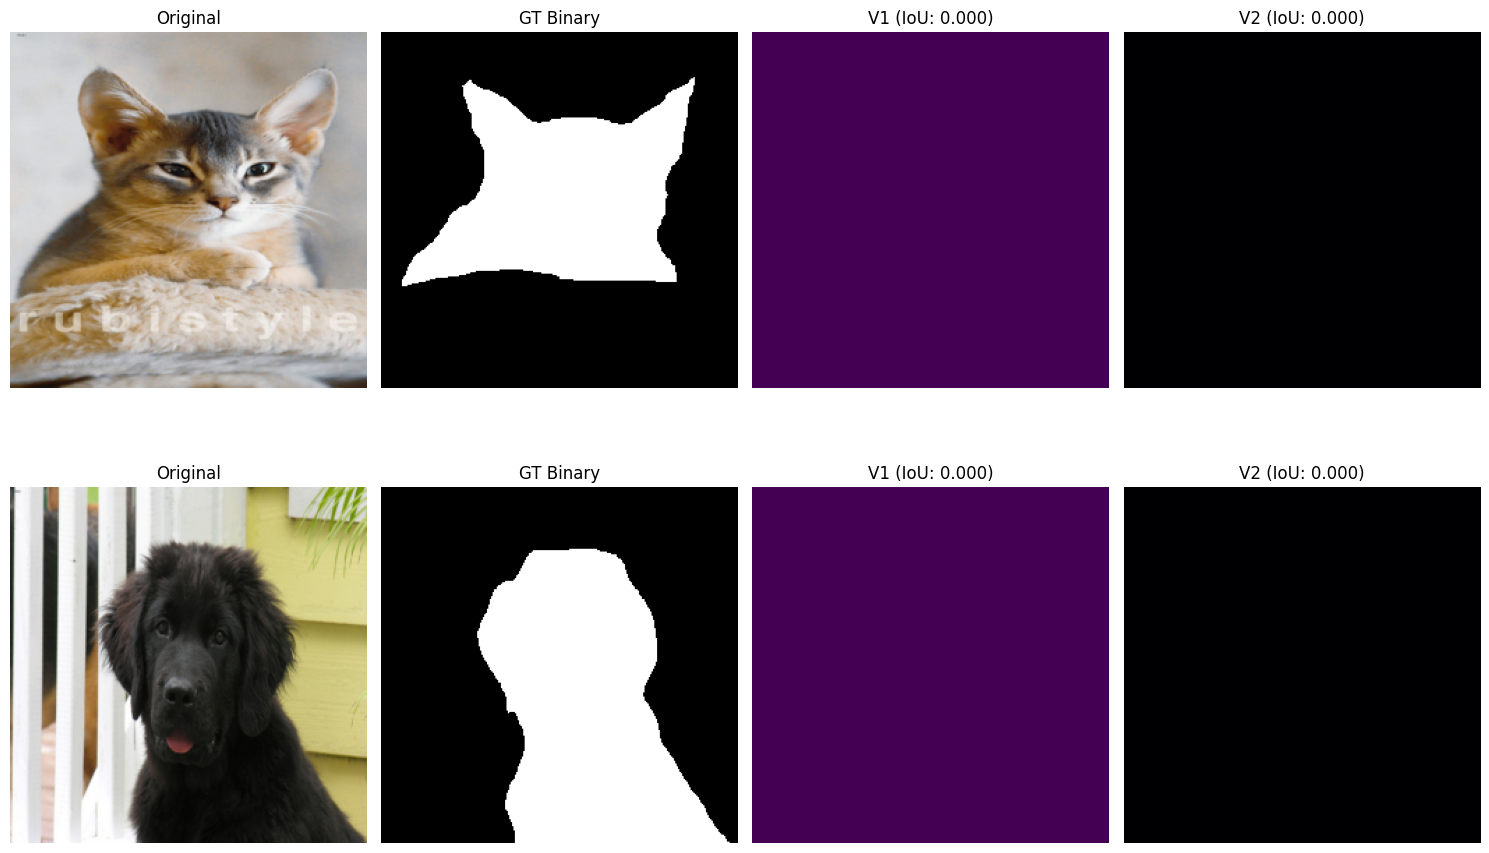

In [12]:
from torchvision.models.segmentation import deeplabv3_resnet50, DeepLabV3_ResNet50_Weights

weights = DeepLabV3_ResNet50_Weights.DEFAULT
model_b = deeplabv3_resnet50(weights=weights).to(device)
model_b.eval()


FOREGROUND_CLASSES = [15, 16]

def get_refined_mask(output, mode='V1'):

    probs = torch.softmax(output, dim=1)
    
    fg_probs = probs[:, FOREGROUND_CLASSES, :, :].sum(dim=1)
    
    if mode == 'V1':
        mask = (fg_probs > 0.5).long()
    else:
        mask = (fg_probs > 0.8).long()
        
    return mask

@torch.no_grad()
def evaluate_segmentation_modes(model, loader, device):
    results = []
    
    images, gt_masks = next(iter(loader))
    images = images.to(device)

    gt_binary = (gt_masks == 1).long()
    
    outputs = model(images)['out']
    
    for mode in ['V1', 'V2']:
        pred_masks = get_refined_mask(outputs, mode=mode).cpu()
        
        ious = []
        for i in range(len(images)):
            iou = calculate_iou(pred_masks[i], gt_binary[i])
            ious.append(iou)
        
        avg_iou = np.mean(ious)
        results.append((mode, avg_iou, pred_masks))
        
        # Логируем в runs.csv
        save_to_runs(f"PartB_Seg_{mode}", {"mean_iou": avg_iou})

    plt.figure(figsize=(15, 10))
    for i in range(2): # покажем 2 примера
        plt.subplot(2, 4, i*4 + 1)
        img_show = images[i].permute(1, 2, 0).cpu().numpy()
        img_show = np.clip(img_show * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406], 0, 1)
        plt.imshow(img_show)
        plt.title("Original")
        plt.axis('off')
        
        # GT
        plt.subplot(2, 4, i*4 + 2)
        plt.imshow(gt_binary[i], cmap='gray')
        plt.title("GT Binary")
        plt.axis('off')
        
        # V1
        plt.subplot(2, 4, i*4 + 3)
        plt.imshow(results[0][2][i], cmap='viridis')
        plt.title(f"V1 (IoU: {results[0][1]:.3f})")
        plt.axis('off')
        
        # V2
        plt.subplot(2, 4, i*4 + 4)
        plt.imshow(results[1][2][i], cmap='magma')
        plt.title(f"V2 (IoU: {results[1][1]:.3f})")
        plt.axis('off')
        
    plt.tight_layout()
    plt.show()

evaluate_segmentation_modes(model_b, loader_b, device)

Лучшая модель: C4 с Val Accuracy: 0.9650


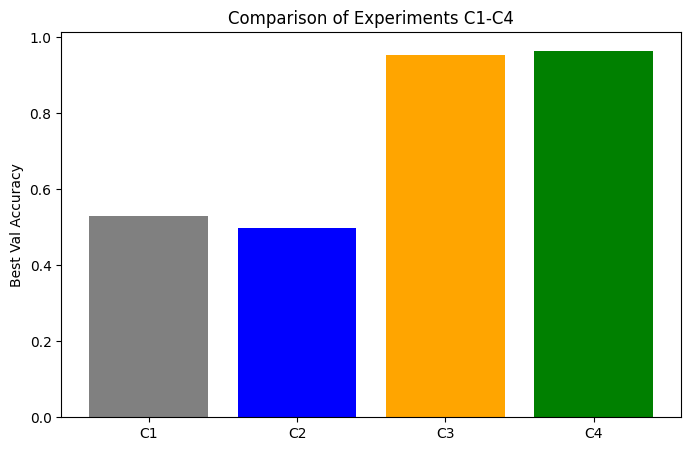

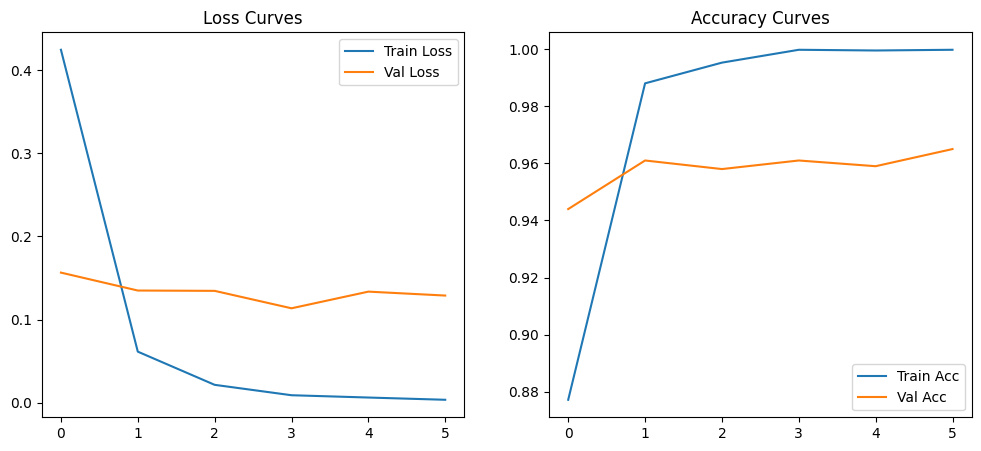

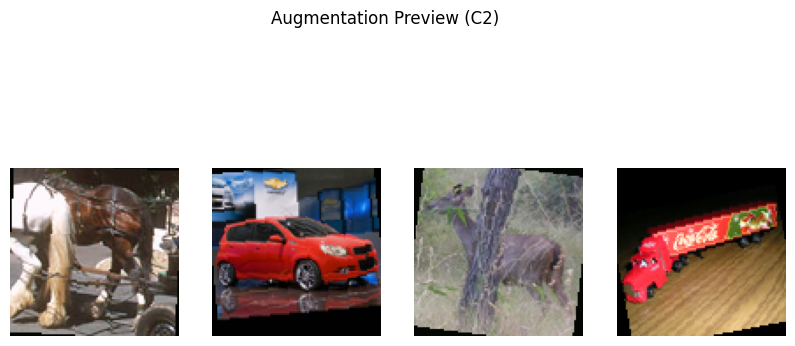

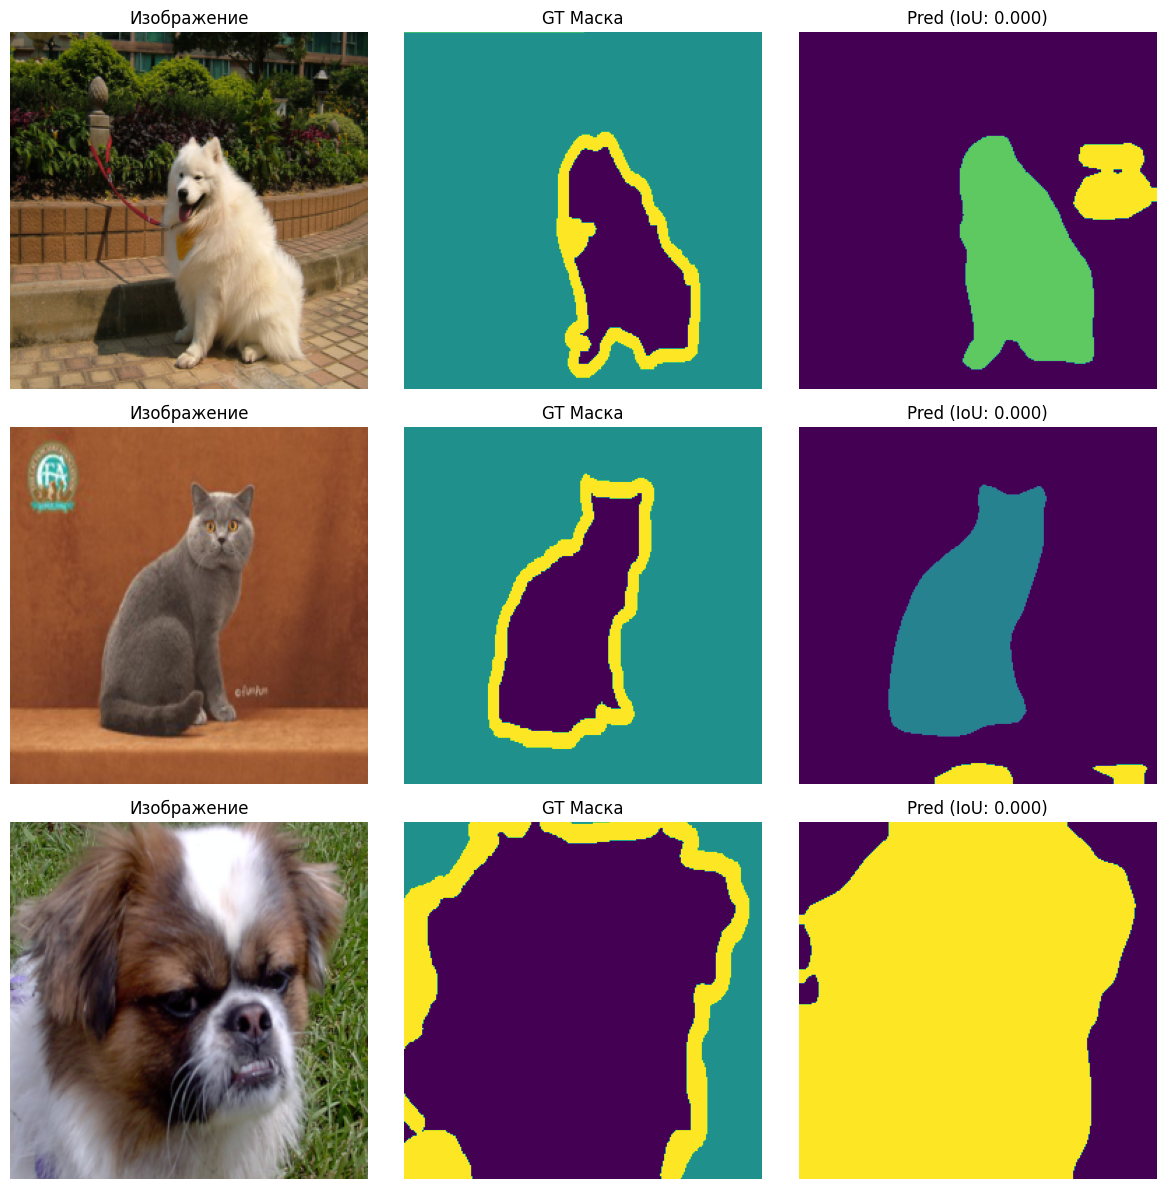

<Figure size 640x480 with 0 Axes>

In [13]:

test_dataset_res = torchvision.datasets.STL10(
    root='./data', split='test', download=True, transform=resnet_transform
)
test_loader_res = DataLoader(test_dataset_res, batch_size=32, shuffle=False)



histories = {'C1': hist_c1, 'C2': hist_c2, 'C3': hist_c3, 'C4': hist_c4}
models = {'C1': model_c1, 'C2': model_c2, 'C3': model_c3, 'C4': model_c4}

best_id = max(histories, key=lambda k: max(histories[k]['val_acc']))
best_model = models[best_id]
best_val_acc = max(histories[best_id]['val_acc'])

print(f"Лучшая модель: {best_id} с Val Accuracy: {best_val_acc:.4f}")


current_test_loader = test_loader_a if best_id in ['C1', 'C2'] else test_loader_res
test_loss, test_acc = evaluate(best_model, current_test_loader, criterion, device)

torch.save(best_model.state_dict(), 'artifacts/best_classifier.pt')

config = {
    "experiment_id": best_id,
    "dataset": "STL10",
    "architecture": "SimpleCNN" if best_id in ['C1', 'C2'] else "ResNet18",
    "best_val_accuracy": best_val_acc,
    "test_accuracy": test_acc,
    "seed": SEED,
    "epochs": EPOCHS
}

with open('artifacts/best_classifier_config.json', 'w') as f:
    json.dump(config, f, indent=4)

os.makedirs('artifacts/figures', exist_ok=True)

plt.figure(figsize=(8, 5))
accs = [max(h['val_acc']) for h in histories.values()]
plt.bar(histories.keys(), accs, color=['gray', 'blue', 'orange', 'green'])
plt.ylabel('Best Val Accuracy')
plt.title('Comparison of Experiments C1-C4')
plt.savefig('artifacts/figures/classification_compare.png')
plt.show()

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(histories[best_id]['train_loss'], label='Train Loss')
plt.plot(histories[best_id]['val_loss'], label='Val Loss')
plt.legend(); plt.title('Loss Curves')

plt.subplot(1, 2, 2)
plt.plot(histories[best_id]['train_acc'], label='Train Acc')
plt.plot(histories[best_id]['val_acc'], label='Val Acc')
plt.legend(); plt.title('Accuracy Curves')
plt.savefig('artifacts/figures/classification_curves_best.png')
plt.show()

images, _ = next(iter(train_loader_aug))
plt.figure(figsize=(10, 5))
for i in range(4):
    plt.subplot(1, 4, i+1)
    img = images[i].permute(1, 2, 0).numpy()
    img = np.clip(img * [0.26, 0.25, 0.27] + [0.44, 0.43, 0.40], 0, 1)
    plt.imshow(img)
    plt.axis('off')
plt.suptitle('Augmentation Preview (C2)')
plt.savefig('artifacts/figures/augmentations_preview.png')
plt.show()

visualize_predictions(model_b, loader_b, device, num_samples=3)
plt.gcf().savefig('artifacts/figures/segmentation_examples.png')



In [ ]:

metrics_v1 = {
    "precision": float(np.mean(p1_list)),
    "recall": float(np.mean(r1_list)),
    "mean_iou": float(np.mean(i1_list)),
}
metrics_v2 = {
    "precision": float(np.mean(p2_list)),
    "recall": float(np.mean(r2_list)),
    "mean_iou": float(np.mean(i2_list)),
}
labels = ["precision", "recall", "mean_iou"]
v1_vals = [metrics_v1[k] for k in labels]
v2_vals = [metrics_v2[k] for k in labels]
x = np.arange(len(labels))
width = 0.36
fig2, ax2 = plt.subplots(figsize=(8, 4))
ax2.bar(x - width / 2, v1_vals, width, label="V1")
ax2.bar(x + width / 2, v2_vals, width, label="V2")
ax2.set_xticks(x)
ax2.set_xticklabels(labels)
ax2.set_ylim(0, 1)
ax2.set_title("Segmentation metrics")
ax2.legend()
fig2.tight_layout()
fig2.savefig(FIGURES_DIR / "segmentation_metrics.png", dpi=150)
plt.show()